# 이상지질혈증 예측 - XGBoost v4 Feature Engineering 실험

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 모델: XGBoost (Optuna 최적 파라미터 고정)
- Threshold: 0.45 고정
- 목적: **피처 추가·제거 실험으로 성능 변화 확인**
- 목표: **Recall ≥ 0.80 유지하면서 F1 ≥ 0.60**
- 검증: Stratified 5-Fold CV

In [1]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed_v4.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD = 0.45

## 1. 데이터 로드

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (22102, 31)


## 2. ✏️ Feature Engineering 설정

> **실험 방법:** 추가하고 싶은 피처 함수의 주석을 해제하세요.
> 순서 중요: `add_age_bin` → `add_family_sum` → 나머지

In [3]:
# ── 피처 엔지니어링 함수 import ──────────────────────────────

# ── 적용할 피처 선택 (주석 해제 = 적용) ──────────────────────
# df = add_age_bin(df, drop_original=False)                  # 나이_구간
# df = add_age_bin5(df, drop_original=False)                 # 나이_5구간

# 가족력 실험
# df = add_family_sum(df, diabetes=True, hypertension=False, dyslipidemia=False,
#                     drop_original=True) # 가족력_3종_제거 + 가족력_합산
# df = df.drop(columns=[
#     '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제',
#     '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제',]) # 가족력 실험

# BMI 실험
# df = add_bmi_bin(df, korean_standard=True, drop_original=True) # BMI_구간(True: 한국인 기준, False: WHO 기준)
# df = df.drop(columns=[ '키', '체중',]) # BMI 실험

# df = add_alcohol_load(df, drop_original=True)  # 음주_총부하 (필요 시 해제)
# df = add_exercise_total(df, drop_original=False)         # 총운동일수 (필요 시 해제)
# df = add_body_features(df, weight_height_ratio=True, bmi_age_interaction=False, drop_original=True) # 체형 복합 (필요 시 해제)
# df = add_age_family_interaction(df, hypertension=False, diabetes=True)   # 나이×가족력 (필요 시 해제)


print(f"\n피처 엔지니어링 완료 | shape: {df.shape}")


피처 엔지니어링 완료 | shape: (22102, 31)


## 3. 피처 / 타겟 분리

In [4]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}  |  정상: {neg}  |  이상지질혈증: {pos}")
print(f"사용 피처 수: {X.shape[1]}")
print(f"피처 목록: {list(X.columns)}")

샘플 수: 21404  |  정상: 14615  |  이상지질혈증: 6789
사용 피처 수: 28
피처 목록: ['성별', '나이', '현재흡연', '걷기일수', '근력운동일수', '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제', '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제', '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제', '키', '체중', 'BMI', '직업_관리전문', '직업_사무', '직업_서비스판매', '직업_농림어업', '직업_기능노무', '직업_주부학생', '직업_무직', '직업_작업미상', '과거음주_현재금주', '음주빈도_enc', '음주량_enc']


## 4. Optuna 최적 파라미터 설정

In [5]:
best_params = {
    "n_estimators": 556,
    "learning_rate": 0.03359654467879424,
    "max_depth": 3,
    "min_child_weight": 7,
    "subsample": 0.7171392533948017,
    "colsample_bytree": 0.7645138588001924,
    "gamma": 0.4590243461447459,
    "reg_alpha": 0.9608771169328996,
    "reg_lambda": 2.4029958024649534,
    "scale_pos_weight": ratio,
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
}
print("파라미터 설정 완료")

파라미터 설정 완료


## 5. Stratified 5-Fold CV

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.7788 | Recall: 0.8689 | F1: 0.6034 | best_iter: 384
  Fold 2 | AUC: 0.7777 | Recall: 0.8873 | F1: 0.6094 | best_iter: 342
  Fold 3 | AUC: 0.7721 | Recall: 0.8719 | F1: 0.6105 | best_iter: 474
  Fold 4 | AUC: 0.7759 | Recall: 0.8733 | F1: 0.6073 | best_iter: 261
  Fold 5 | AUC: 0.7872 | Recall: 0.8865 | F1: 0.6139 | best_iter: 281
  평균   | AUC: 0.7784±0.0056 | Recall: 0.8776±0.0087 | F1: 0.6089±0.0039


## 6. OOF proba 저장 (.npy)

In [7]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_xgboost_v4.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_HL_xgboost_v4.npy
로드 확인: shape=(21404, 2), 일치=True


## 7. OOF 성능 & 기준 모델 비교

In [8]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# 기준 모델 (FE 없음, Optuna)
BASE = {"auc": 0.7782, "recall": 0.8776, "precision": 0.4662, "f1": 0.6089, "acc": 0.6424, "fp": 6823, "fn": 831}

print("=" * 55)
print(f"  {'지표':<12}  {'기준 모델':>12}  {'FE 적용':>10}  변화")
print("=" * 55)
for label, base_v, cur_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = cur_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>12}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>12}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 55)
print("\n[분류 리포트]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "이상지질혈증(1)"]))

  지표                   기준 모델       FE 적용  변화
  AUC-ROC             0.7782      0.7782  ▼ 0.0000
  Recall              0.8776      0.8776  ▼ 0.0000
  Precision           0.4662      0.4662  ▼ 0.0000
  F1-score            0.6089      0.6089  ▼ 0.0000
  Accuracy            0.6424      0.6424  ▲ 0.0000
  FP                    6823        6823  ▲ 0
  FN                     831         831  ▲ 0

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.90      0.53      0.67     14615
   이상지질혈증(1)       0.47      0.88      0.61      6789

    accuracy                           0.64     21404
   macro avg       0.68      0.71      0.64     21404
weighted avg       0.76      0.64      0.65     21404



## 8. Confusion Matrix

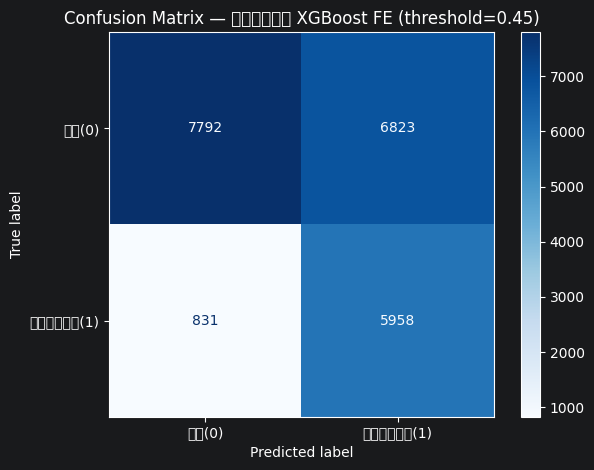

In [9]:
disp = ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "이상지질혈증(1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — 이상지질혈증 XGBoost FE (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 9. Feature Importance (XGBoost, 5-Fold 평균)

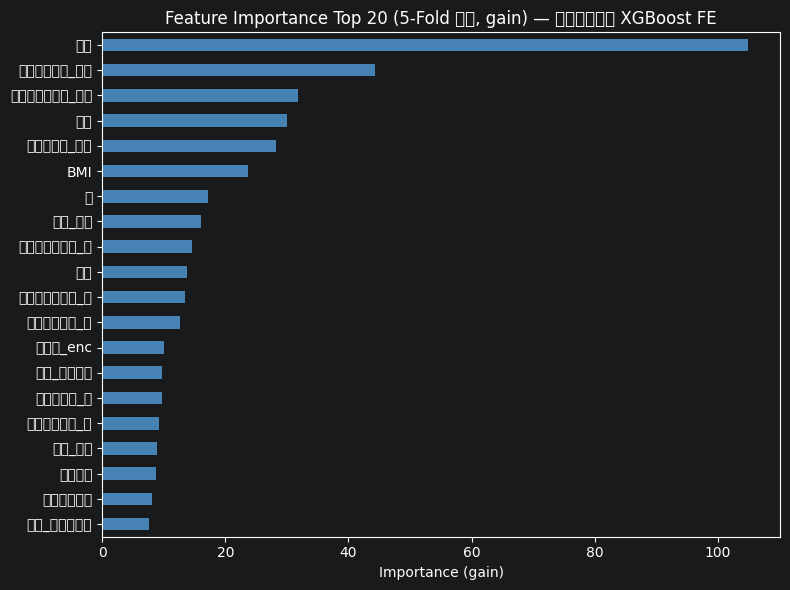

   1. 나이: 104.8
   2. 고혈압가족력_형제: 44.2
   3. 고지혈증가족력_형제: 31.8
   4. 성별: 30.0
   5. 당뇨가족력_형제: 28.2
   6. BMI: 23.7
   7. 키: 17.3
   8. 직업_무직: 16.0
   9. 고지혈증가족력_모: 14.7
  10. 체중: 13.9
  11. 고지혈증가족력_부: 13.4
  12. 고혈압가족력_모: 12.7
  13. 음주량_enc: 10.1
  14. 직업_관리전문: 9.7
  15. 당뇨가족력_모: 9.7
  16. 고혈압가족력_부: 9.3
  17. 직업_사무: 8.9
  18. 현재흡연: 8.7
  19. 근력운동일수: 8.1
  20. 직업_서비스판매: 7.7


In [10]:
fi_list = []
for fold, (tr_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y), 1
):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = xgb.XGBClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    gain = pd.Series(m.get_booster().get_score(importance_type="gain"))
    gain = gain.reindex(X.columns, fill_value=0)
    fi_list.append(gain)

fi = pd.DataFrame(fi_list).mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 20 (5-Fold 평균, gain) — 이상지질혈증 XGBoost FE")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()
for i, (feat, imp) in enumerate(fi.head(20).items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.1f}")

## 10. SHAP 분석 (OOF 전체 기준)

SHAP Fold 1 완료
SHAP Fold 2 완료
SHAP Fold 3 완료
SHAP Fold 4 완료
SHAP Fold 5 완료


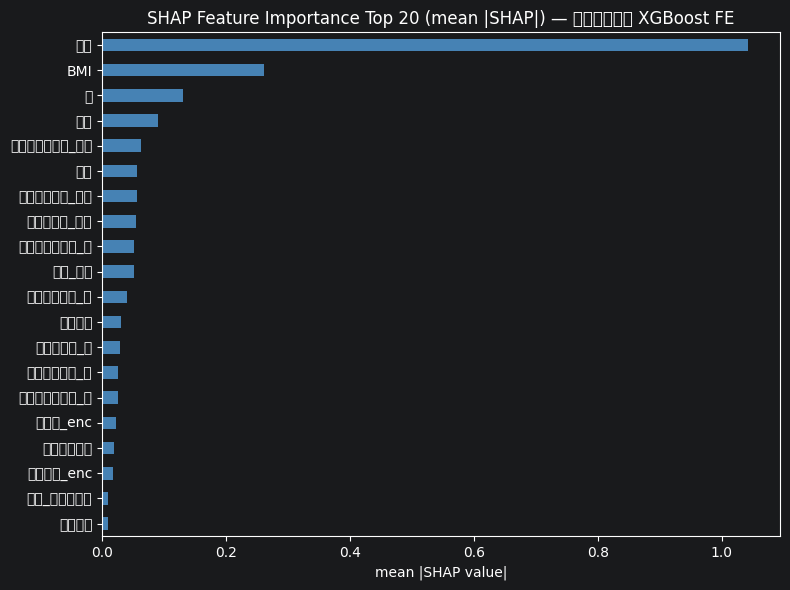

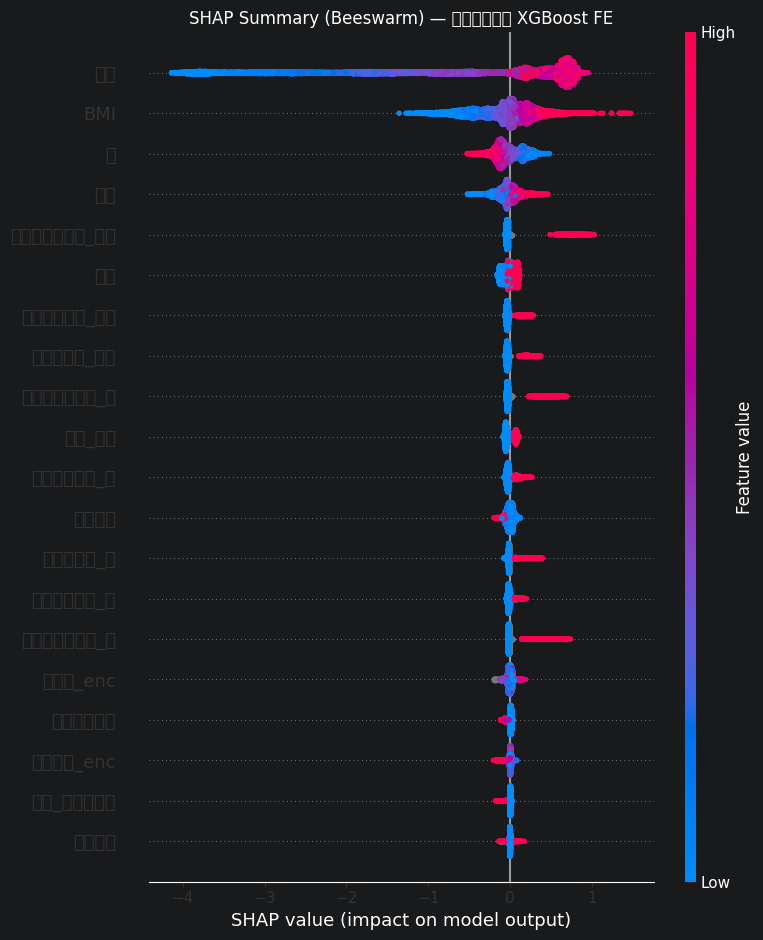

[SHAP Top 15]
   1. 나이: 1.0422
   2. BMI: 0.2619
   3. 키: 0.1309
   4. 체중: 0.0902
   5. 고지혈증가족력_형제: 0.0624
   6. 성별: 0.0567
   7. 고혈압가족력_형제: 0.0558
   8. 당뇨가족력_형제: 0.0550
   9. 고지혈증가족력_모: 0.0522
  10. 직업_무직: 0.0515
  11. 고혈압가족력_모: 0.0395
  12. 걷기일수: 0.0307
  13. 당뇨가족력_모: 0.0285
  14. 고혈압가족력_부: 0.0263
  15. 고지혈증가족력_부: 0.0261


In [11]:
import shap

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
shap_values = np.zeros(X.shape)

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = xgb.XGBClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    explainer = shap.TreeExplainer(m)
    shap_values[val_idx] = explainer.shap_values(X_val)
    print(f"SHAP Fold {fold} 완료")

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

# SHAP Bar
plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — 이상지질혈증 XGBoost FE")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

# SHAP Beeswarm
shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 이상지질혈증 XGBoost FE", fontsize=12)
plt.tight_layout()
plt.show()

print("[SHAP Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 11. DB 로그 저장

In [12]:
sys.path.insert(0, os.path.join(BASE_DIR))
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))

base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE 적용: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="XGBoost",
    stage="v4_fe_exp",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "n_estimators": best_params["n_estimators"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "min_child_weight": best_params["min_child_weight"],
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],
        "gamma": best_params["gamma"],
        "reg_alpha": best_params["reg_alpha"],
        "reg_lambda": best_params["reg_lambda"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=gain.head(15).to_dict(),
    note=fe_note,
)
print(f"저장 완료 → run_id: {run_id}  |  {fe_note}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=133 | 이상지질혈증 XGBoost (v4_fe_exp)
저장 완료 → run_id: 133  |  FE 없음
 run_id          created_at target_var model_name             stage  auc_roc   recall  precision  f1_score  accuracy
    133 2026-05-20 17:39:13     이상지질혈증    XGBoost         v4_fe_exp 0.778153 0.877596   0.466161  0.608891  0.642403
    132 2026-05-20 17:30:40     이상지질혈증    XGBoost v4_threshold_0.45 0.778153 0.877596   0.466161  0.608891  0.642403
    131 2026-05-20 17:16:28         당뇨   CatBoost         v4_fe_exp 0.806710 0.813865   0.479754  0.603663  0.693787
    130 2026-05-20 17:05:00         당뇨   CatBoost v4_threshold_0.50 0.806710 0.813865   0.479754  0.603663  0.693787
    129 2026-05-20 17:02:43         당뇨   CatBoost v4_threshold_0.50 0.828401 0.804527   0.510085  0.624332  0.722585
    128 2026-05-20 17:00:30         당뇨   CatBoost v4_threshold_0.50 0.828401 0.804527   0.510085  0.624332  0.722585
    127 2026-05-20 17:00:16         당뇨   CatBoost v4_threshold_0.50 0.828409 0.808009   0